# Sensitivity Analysis: Cinema Showtime Optimization

This notebook performs sensitivity analysis on the showtime optimization model to understand:
1. How ticket price changes affect revenue
2. Impact of buffer time between shows
3. Effect of maximum showings per movie per day
4. Impact of demand variations
5. Screen capacity constraints
6. Operating hours sensitivity

In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Baseline Results and Data

In [2]:
# Load baseline results
results_dir = Path("results")

baseline_schedule = pd.read_csv(results_dir / "baseline_schedule.csv")
baseline_realized = pd.read_csv(results_dir / "baseline_realized.csv")
baseline_summary = pd.read_csv(results_dir / "baseline_summary.csv")
baseline_params = pd.read_csv(results_dir / "baseline_parameters.csv")
movie_data = pd.read_csv(results_dir / "movie_data.csv")
demand_data = pd.read_csv(results_dir / "demand_data.csv")

print("Baseline Results Loaded:")
print("="*60)
for _, row in baseline_summary.iterrows():
    print(f"{row['metric']}: {row['value']:,.2f}")

Baseline Results Loaded:
total_revenue: 346,048.47
total_showings: 96.00
total_tickets_sold: 27,992.00
num_movies_scheduled: 98.00
num_screens_used: 8.00
avg_showings_per_movie: 8.43
avg_tickets_per_showing: 237.22
capacity_utilization: 1.13


## Setup: Import Model Creation Function

In [3]:
# Theater configuration
NUM_SCREENS = 19
SCREENS = [f"Screen_{i}" for i in range(1, NUM_SCREENS+1)]
SCREEN_CAPACITIES = {s: 210 for s in SCREENS[:19]}
SCREEN_CAPACITIES["Screen_19"] = 600

DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Get baseline parameters
def get_param(name):
    return baseline_params[baseline_params['parameter'] == name]['value'].values[0]

BASELINE_TICKET_PRICE = get_param('ticket_price')
BASELINE_BUFFER_MIN = get_param('buffer_min')
BASELINE_MAX_SHOWINGS = int(get_param('max_showings_per_movie_per_day'))
BASELINE_OPERATING_HOURS = get_param('operating_hours_per_day')

# Enhanced model parameters
BASE_TICKET_PRICE = BASELINE_TICKET_PRICE  # Reference price for elasticity calculations
PRICE_ELASTICITY = 1.2  # Demand decreases by 1.2% for every 1% price increase
GENRE_DIVERSITY_WEIGHT = 0.05  # 5% revenue boost per genre above minimum
MIN_GENRES = 5  # Minimum genres required per day
MIN_GENRES_FOR_BONUS = 5  # Baseline genre count for bonus calculation
MAX_GENRE_BONUS = 0.25  # Cap at 25% demand boost

# Movie repetition and variety parameters
REPETITION_PENALTY_WEIGHT = 100  # Cost per showing squared
MOVIE_DIVERSITY_WEIGHT = 200  # Bonus per unique movie scheduled

print(f"Baseline Parameters:")
print(f"  Ticket Price: ${BASELINE_TICKET_PRICE:.2f}")
print(f"  Buffer Time: {BASELINE_BUFFER_MIN:.0f} minutes")
print(f"  Max Showings/Movie/Day: {BASELINE_MAX_SHOWINGS}")
print(f"  Operating Hours: {BASELINE_OPERATING_HOURS:.1f} hours")
print(f"\nEnhanced Model Parameters:")
print(f"  Price Elasticity: {PRICE_ELASTICITY}")
print(f"  Genre Diversity Weight: {GENRE_DIVERSITY_WEIGHT:.1%}")
print(f"  Min Genres: {MIN_GENRES}")
print(f"  Min Genres for Bonus: {MIN_GENRES_FOR_BONUS}")
print(f"  Repetition Penalty Weight: ${REPETITION_PENALTY_WEIGHT}")
print(f"  Movie Diversity Weight: ${MOVIE_DIVERSITY_WEIGHT}")

Baseline Parameters:
  Ticket Price: $11.31
  Buffer Time: 15 minutes
  Max Showings/Movie/Day: 5
  Operating Hours: 12.0 hours

Enhanced Model Parameters:
  Price Elasticity: 1.2
  Genre Diversity Weight: 5.0%
  Min Genres: 5
  Min Genres for Bonus: 5
  Repetition Penalty Weight: $100
  Movie Diversity Weight: $200


In [ ]:
# Prepare data structures
movie_ids = movie_data['movie_id'].tolist()
runtimes = dict(zip(movie_data['movie_id'], movie_data['runtime']))

# Create demand dictionary from loaded data
demand = {}
for _, row in demand_data.iterrows():
    demand[(row['movie_id'], row['day'])] = row['demand']

# Load movie genre data for diversity constraints
import sys
from pathlib import Path
project_root = Path.cwd().parent
movies_df = pd.read_csv(project_root / "data/cleaned/final_merged_dataset_with_genres.csv")
current = movies_df[movies_df['release_date'] > '2025-10-01']

print(f"\nData Loaded:")
print(f"  Movies: {len(movie_ids)}")
print(f"  Total demand entries: {len(demand)}")
print(f"  Movies with genre data: {len(current)}")


Data Loaded:
  Movies: 14
  Total demand entries: 98
  Movies with genre data: 14


In [ ]:
def createModel(runtimes, demand, ticket_price, max_showings_per_day, operating_min_per_day, 
                screen_capacity, movie_ids, days, screens, buffer_min, 
                movie_genre_df=None, min_genres=None,
                base_price=None, price_elasticity=None,
                genre_diversity_weight=None, min_genres_for_bonus=None, max_genre_bonus=None,
                repetition_penalty_weight=None, movie_diversity_weight=None,
                verbose=False):
    """
    Create enhanced optimization model with price elasticity, genre diversity, and repetition penalty
    """
    m = gp.Model("CinemaShowtimeScheduling")
    if not verbose:
        m.Params.OutputFlag = 0
    
    # Adjust demand based on price elasticity
    adjusted_demand = {}
    if base_price is not None and price_elasticity is not None and base_price > 0:
        price_ratio = base_price / ticket_price
        demand_multiplier = price_ratio ** price_elasticity
        for key, val in demand.items():
            adjusted_demand[key] = val * demand_multiplier
    else:
        adjusted_demand = demand.copy()
    
    # Decision variables
    x = m.addVars(movie_ids, days, screens, vtype=GRB.INTEGER, lb=0, name="x")
    r = m.addVars(movie_ids, days, vtype=GRB.CONTINUOUS, lb=0.0, name="r")
    s = m.addVars(movie_ids, days, vtype=GRB.BINARY, name="s")
    
    # Objective: maximize total revenue from ticket sales
    revenue_from_tickets = gp.quicksum(ticket_price * r[i, d] for i in movie_ids for d in days)
    objective_expr = revenue_from_tickets
    g = None
    
    # Add genre diversity bonus if enabled
    if (movie_genre_df is not None and genre_diversity_weight is not None and 
        min_genres_for_bonus is not None):
        
        genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                        'documentary', 'drama', 'family', 'fantasy', 'history', 
                        'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                        'thriller', 'tv_movie', 'war', 'western']
        
        g = m.addVars(genre_columns, days, vtype=GRB.BINARY, name="genre")
        
        avg_daily_revenue = revenue_from_tickets / len(days)
        total_genre_count = gp.quicksum(g[genre, d] for genre in genre_columns for d in days)
        avg_genres_per_day = total_genre_count / len(days)
        
        diversity_bonus = avg_daily_revenue * genre_diversity_weight * (avg_genres_per_day - min_genres_for_bonus)
        objective_expr = objective_expr + diversity_bonus
    
    # Add movie diversity bonus
    if movie_diversity_weight is not None and movie_diversity_weight > 0:
        movie_diversity_bonus = movie_diversity_weight * gp.quicksum(s[i, d] for i in movie_ids for d in days)
        objective_expr = objective_expr + movie_diversity_bonus
    
    # Add repetition penalty
    if repetition_penalty_weight is not None and repetition_penalty_weight > 0:
        total_showings = {}
        for i in movie_ids:
            for d in days:
                total_showings[(i, d)] = gp.quicksum(x[i, d, j] for j in screens)
        
        repetition_penalty = repetition_penalty_weight * gp.quicksum(
            total_showings[(i, d)] * total_showings[(i, d)] for i in movie_ids for d in days
        )
        objective_expr = objective_expr - repetition_penalty
    
    m.setObjective(objective_expr, GRB.MAXIMIZE)
    
    # Constraints
    for d in days:
        for j in screens:
            m.addConstr(
                gp.quicksum(x[i, d, j] * (runtimes[i] + buffer_min) for i in movie_ids)
                <= operating_min_per_day[d],
                name=f"Time_{d}_{j}"
            )
    
    for i in movie_ids:
        for d in days:
            m.addConstr(
                r[i, d] <= gp.quicksum(x[i, d, j] * screen_capacity[j] for j in screens),
                name=f"Capacity_{i}_{d}"
            )
    
    for i in movie_ids:
        for d in days:
            demand_val = adjusted_demand.get((i, d), 0)
            m.addConstr(r[i, d] <= demand_val, name=f"Demand_{i}_{d}")
    
    for i in movie_ids:
        for d in days:
            m.addConstr(
                gp.quicksum(x[i, d, j] for j in screens)
                <= max_showings_per_day * s[i, d],
                name=f"FreqLimit_{i}_{d}"
            )
    
    # Genre diversity constraints
    if g is not None:
        genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                        'documentary', 'drama', 'family', 'fantasy', 'history', 
                        'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                        'thriller', 'tv_movie', 'war', 'western']
        
        for genre in genre_columns:
            for d in days:
                movies_with_genre = [i for i in movie_ids 
                                    if i in movie_genre_df.index and 
                                    movie_genre_df.loc[i, genre] == 1]
                
                if movies_with_genre:
                    m.addConstr(
                        g[genre, d] <= gp.quicksum(s[i, d] for i in movies_with_genre),
                        name=f"GenreUpper_{genre}_{d}"
                    )
                    
                    for i in movies_with_genre:
                        m.addConstr(
                            s[i, d] <= g[genre, d],
                            name=f"GenreLower_{genre}_{d}_{i}"
                        )
        
        if min_genres is not None and min_genres > 0:
            for d in days:
                m.addConstr(
                    gp.quicksum(g[genre, d] for genre in genre_columns) >= min_genres,
                    name=f"MinGenres_{d}"
                )
    
    return m, x, r, s, g

def run_optimization(runtimes, demand, ticket_price, max_showings_per_day, 
                     operating_min_per_day, screen_capacity, movie_ids, days, 
                     screens, buffer_min, movie_genre_df=None, min_genres=None,
                     base_price=None, price_elasticity=None,
                     genre_diversity_weight=None, min_genres_for_bonus=None,
                     max_genre_bonus=None, repetition_penalty_weight=None,
                     movie_diversity_weight=None, verbose=False):
    """
    Run optimization and extract key metrics
    """
    m, x, r, s, g = createModel(
        runtimes, demand, ticket_price, max_showings_per_day,
        operating_min_per_day, screen_capacity, movie_ids, days, screens, buffer_min,
        movie_genre_df, min_genres, base_price, price_elasticity,
        genre_diversity_weight, min_genres_for_bonus, max_genre_bonus,
        repetition_penalty_weight, movie_diversity_weight, verbose
    )
    m.optimize()
    
    if m.Status == GRB.OPTIMAL:
        total_revenue = m.objVal
        total_tickets = sum(r[i, d].X for i in movie_ids for d in days)
        total_showings = sum(x[i, d, j].X for i in movie_ids for d in days for j in screens)
        
        # Calculate additional metrics
        avg_genres = 0
        unique_movie_days = sum(1 for i in movie_ids for d in days if s[i, d].X > 0.5)
        max_showings_per_movie_day = 0
        
        for i in movie_ids:
            for d in days:
                showings_this_day = sum(x[i, d, j].X for j in screens)
                if showings_this_day > max_showings_per_movie_day:
                    max_showings_per_movie_day = showings_this_day
        
        if g is not None:
            genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                           'documentary', 'drama', 'family', 'fantasy', 'history', 
                           'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                           'thriller', 'tv_movie', 'war', 'western']
            total_genres = sum(g[genre, d].X for genre in genre_columns for d in days)
            avg_genres = total_genres / len(days)
        
        return {
            'revenue': total_revenue,
            'tickets': total_tickets,
            'showings': total_showings,
            'avg_genres': avg_genres,
            'unique_movie_days': unique_movie_days,
            'max_showings_per_movie_day': max_showings_per_movie_day,
            'status': 'Optimal'
        }
    else:
        return {
            'revenue': 0,
            'tickets': 0,
            'showings': 0,
            'avg_genres': 0,
            'unique_movie_days': 0,
            'max_showings_per_movie_day': 0,
            'status': f'Status_{m.Status}'
        }

print("Enhanced model functions defined successfully!")

Enhanced model functions defined successfully!


## 1. Ticket Price Sensitivity Analysis

In [6]:
# Test different ticket prices WITH price elasticity
price_range = np.arange(8, 18, 0.5)
price_results = []

print("Running ticket price sensitivity analysis (WITH price elasticity)...")
operating_min = {day: BASELINE_OPERATING_HOURS * 60 for day in DAYS}

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    price_results.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings'],
        'avg_genres': result['avg_genres']
    })
    print(f"  Price ${price:.2f}: Revenue ${result['revenue']:,.2f}, Tickets {result['tickets']:,.0f}")

price_df = pd.DataFrame(price_results)
print("\nTicket price analysis complete!")

# Also run WITHOUT elasticity for comparison
print("\nRunning comparison WITHOUT price elasticity...")
price_results_no_elasticity = []

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=None,  # No elasticity
        price_elasticity=None,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    price_results_no_elasticity.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df_no_elasticity = pd.DataFrame(price_results_no_elasticity)
print("Comparison complete!")

Running ticket price sensitivity analysis (WITH price elasticity)...
Set parameter Username
Set parameter LicenseID to value 2737040
Academic license - for non-commercial use only - expires 2026-11-13
  Price $8.00: Revenue $331,982.56, Tickets 37,725
  Price $8.50: Revenue $335,998.62, Tickets 35,936
  Price $9.00: Revenue $339,160.89, Tickets 34,259
  Price $9.50: Revenue $341,421.44, Tickets 32,672
  Price $10.00: Revenue $343,846.71, Tickets 31,259
  Price $10.50: Revenue $346,419.11, Tickets 29,993
  Price $11.00: Revenue $348,803.39, Tickets 28,827
  Price $11.50: Revenue $349,658.73, Tickets 27,641
  Price $12.00: Revenue $350,638.40, Tickets 26,564
  Price $12.50: Revenue $351,731.29, Tickets 25,580
  Price $13.00: Revenue $352,790.49, Tickets 24,671
  Price $13.50: Revenue $350,137.63, Tickets 23,578
  Price $14.00: Revenue $347,600.13, Tickets 22,571
  Price $14.50: Revenue $345,169.13, Tickets 21,641
  Price $15.00: Revenue $342,836.69, Tickets 20,778
  Price $15.50: Revenue

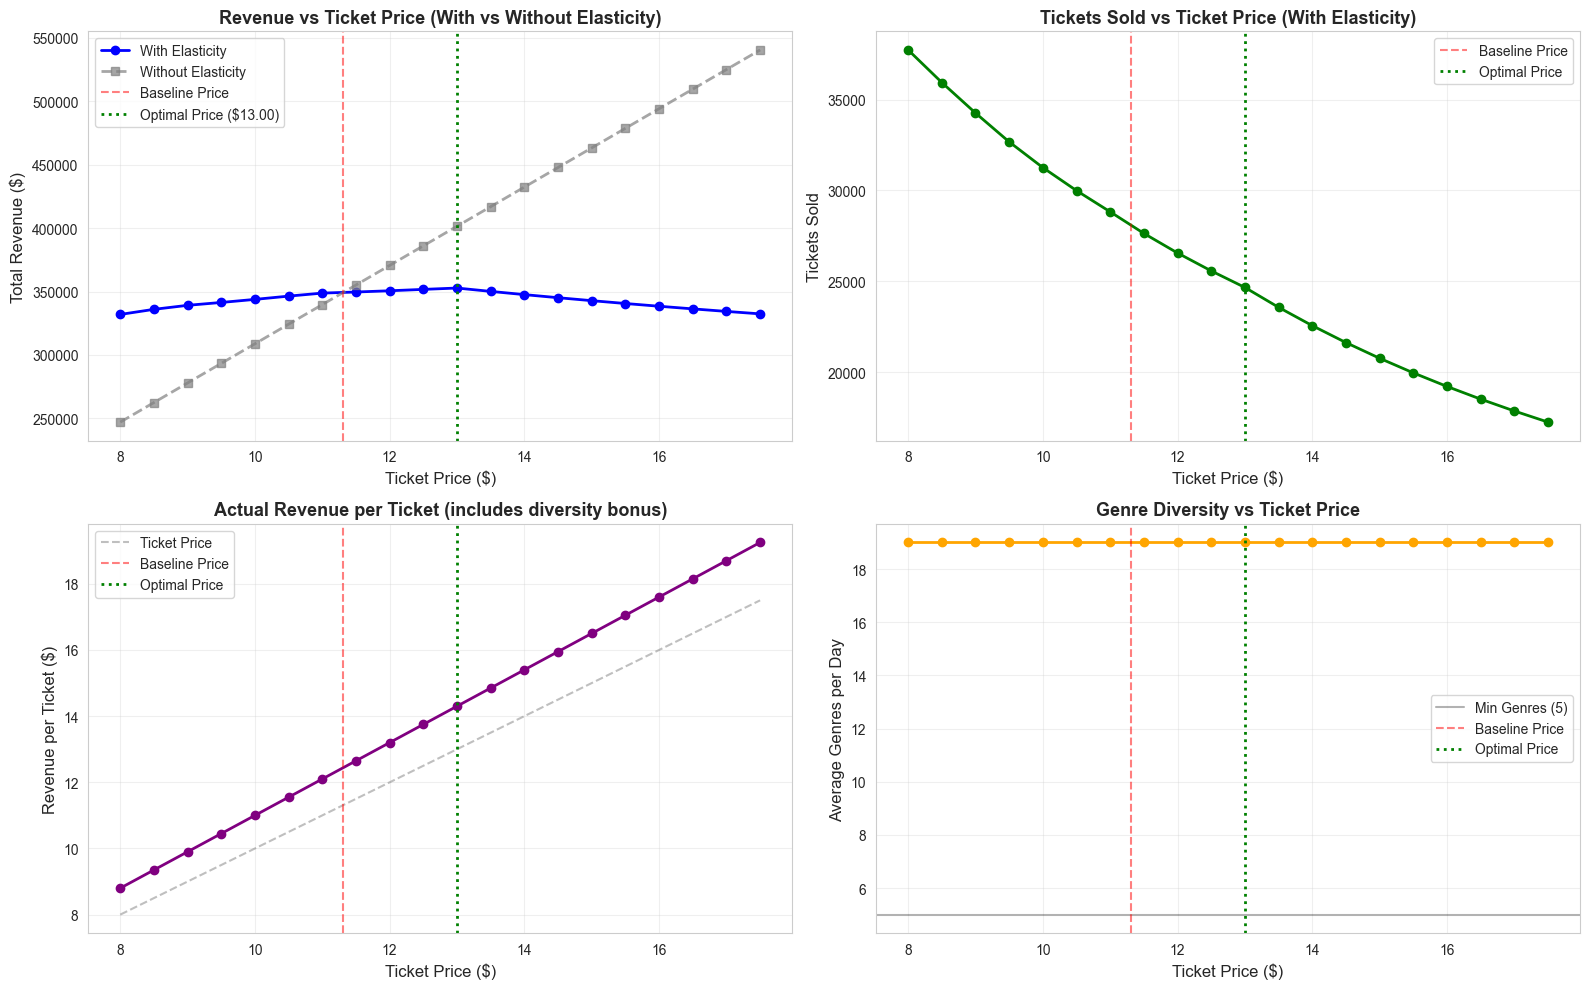


Key Findings:
  Optimal ticket price (with elasticity): $13.00
  Revenue at optimal price: $352,790.49
  Revenue at baseline price: $331,982.56
  Improvement from optimal pricing: $20,807.93


In [7]:
# Visualize ticket price sensitivity - COMPARISON
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue vs Price - COMPARISON
axes[0, 0].plot(price_df['ticket_price'], price_df['revenue'], marker='o', linewidth=2, label='With Elasticity', color='blue')
axes[0, 0].plot(price_df_no_elasticity['ticket_price'], price_df_no_elasticity['revenue'], marker='s', linewidth=2, linestyle='--', label='Without Elasticity', color='gray', alpha=0.7)
axes[0, 0].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
optimal_price_idx = price_df['revenue'].idxmax()
optimal_price = price_df.loc[optimal_price_idx, 'ticket_price']
axes[0, 0].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price (${optimal_price:.2f})', linewidth=2)
axes[0, 0].set_xlabel('Ticket Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0, 0].set_title('Revenue vs Ticket Price (With vs Without Elasticity)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Tickets Sold vs Price
axes[0, 1].plot(price_df['ticket_price'], price_df['tickets'], marker='o', linewidth=2, color='green')
axes[0, 1].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[0, 1].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[0, 1].set_xlabel('Ticket Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Tickets Sold', fontsize=12)
axes[0, 1].set_title('Tickets Sold vs Ticket Price (With Elasticity)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Revenue per Ticket
price_df['revenue_per_ticket'] = price_df['revenue'] / price_df['tickets']
axes[1, 0].plot(price_df['ticket_price'], price_df['revenue_per_ticket'], marker='o', linewidth=2, color='purple')
axes[1, 0].plot(price_df['ticket_price'], price_df['ticket_price'], linestyle='--', color='gray', alpha=0.5, label='Ticket Price')
axes[1, 0].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[1, 0].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[1, 0].set_xlabel('Ticket Price ($)', fontsize=12)
axes[1, 0].set_ylabel('Revenue per Ticket ($)', fontsize=12)
axes[1, 0].set_title('Actual Revenue per Ticket (includes diversity bonus)', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Average Genres per Day
axes[1, 1].plot(price_df['ticket_price'], price_df['avg_genres'], marker='o', linewidth=2, color='orange')
axes[1, 1].axhline(MIN_GENRES, color='black', linestyle='-', alpha=0.3, label=f'Min Genres ({MIN_GENRES})')
axes[1, 1].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[1, 1].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[1, 1].set_xlabel('Ticket Price ($)', fontsize=12)
axes[1, 1].set_ylabel('Average Genres per Day', fontsize=12)
axes[1, 1].set_title('Genre Diversity vs Ticket Price', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_ticket_price_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Optimal ticket price (with elasticity): ${optimal_price:.2f}")
print(f"  Revenue at optimal price: ${price_df.loc[optimal_price_idx, 'revenue']:,.2f}")
print(f"  Revenue at baseline price: ${price_df[price_df['ticket_price'] <= BASELINE_TICKET_PRICE+ 1]['revenue'].values[0]:,.2f}")
print(f"  Improvement from optimal pricing: ${price_df.loc[optimal_price_idx, 'revenue'] - price_df[price_df['ticket_price'] <= BASELINE_TICKET_PRICE+ 1]['revenue'].values[0]:,.2f}")

## 2. Buffer Time Sensitivity Analysis

In [8]:
# Test different buffer times
buffer_range = [0, 5, 10, 15, 20, 25, 30]
buffer_results = []

print("Running buffer time sensitivity analysis...")

for buffer in buffer_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        buffer, verbose=False
    )
    buffer_results.append({
        'buffer_min': buffer,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings']
    })
    print(f"  Buffer {buffer} min: Revenue ${result['revenue']:,.2f}, Showings: {result['showings']:.0f}")

buffer_df = pd.DataFrame(buffer_results)
print("\nBuffer time analysis complete!")

Running buffer time sensitivity analysis...
  Buffer 0 min: Revenue $317,562.18, Showings: 139
  Buffer 5 min: Revenue $317,562.18, Showings: 135
  Buffer 10 min: Revenue $317,562.18, Showings: 129
  Buffer 15 min: Revenue $317,562.18, Showings: 129
  Buffer 20 min: Revenue $317,562.18, Showings: 129
  Buffer 25 min: Revenue $317,562.18, Showings: 132
  Buffer 30 min: Revenue $317,562.18, Showings: 134

Buffer time analysis complete!


## 2. Maximum Showings Per Movie Sensitivity

In [10]:
# Test different max showings constraints
max_showings_range = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]
showings_results = []

print("Running max showings sensitivity analysis...")

for max_show in max_showings_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, max_show,
    
    operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, verbose=False
    )
    showings_results.append({
        'max_showings': max_show,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings']
    })
    print(f"  Max Showings {max_show}: Revenue ${result['revenue']:,.2f}")

showings_df = pd.DataFrame(showings_results)
print("\nMax showings analysis complete!")

Running max showings sensitivity analysis...
  Max Showings 1: Revenue $173,766.84
  Max Showings 2: Revenue $224,605.29
  Max Showings 3: Revenue $271,428.69
  Max Showings 4: Revenue $298,606.62
  Max Showings 5: Revenue $317,562.18
  Max Showings 6: Revenue $329,776.98
  Max Showings 7: Revenue $329,776.98
  Max Showings 8: Revenue $329,776.98
  Max Showings 10: Revenue $329,776.98
  Max Showings 15: Revenue $329,776.98

Max showings analysis complete!


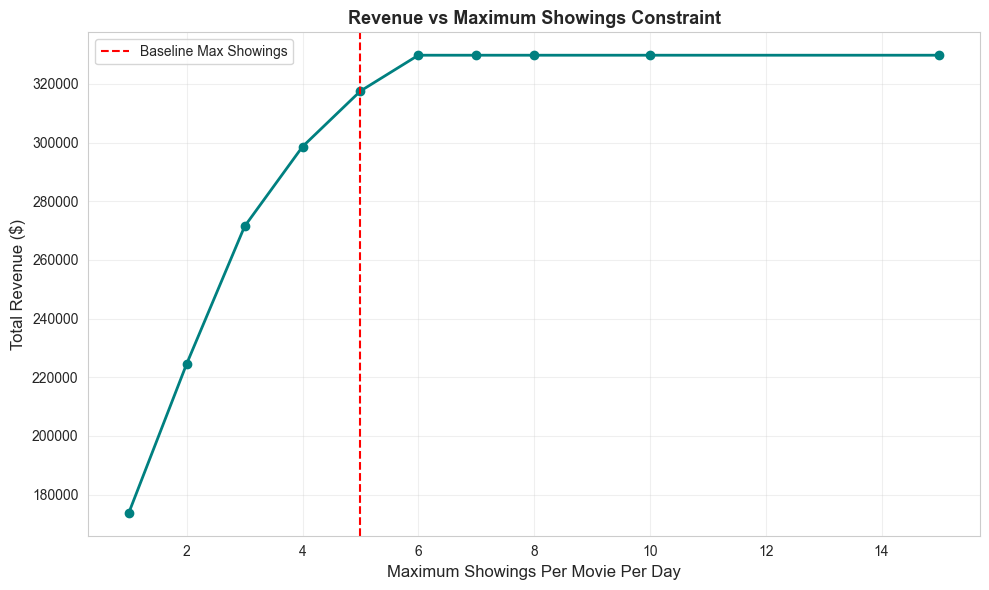

In [11]:
# Visualize max showings sensitivity
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(showings_df['max_showings'], showings_df['revenue'], marker='o', linewidth=2, color='teal')
ax.axvline(BASELINE_MAX_SHOWINGS, color='red', linestyle='--', label='Baseline Max Showings')
ax.set_xlabel('Maximum Showings Per Movie Per Day', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_title('Revenue vs Maximum Showings Constraint', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_max_showings.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Repetition Penalty Weight Sensitivity Analysis

Testing how penalizing repeated showings affects scheduling decisions.

## 9. Movie Diversity Weight Sensitivity Analysis

Testing how rewarding unique movies affects programming variety.

In [14]:
# Test different repetition penalty weights
repetition_weights = [0, 25, 50, 100, 200, 300]
repetition_results = []

print("Running repetition penalty weight sensitivity analysis...")

for weight in repetition_weights:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN,
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        repetition_penalty_weight=weight,
        movie_diversity_weight=MOVIE_DIVERSITY_WEIGHT,
        verbose=False
    )
    repetition_results.append({
        'repetition_penalty_weight': weight,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'avg_genres': result['avg_genres'],
        'unique_movie_days': result['unique_movie_days'],
        'max_showings_per_movie_day': result['max_showings_per_movie_day']
    })
    print(f"  Weight ${weight}: Revenue ${result['revenue']:,.2f}, Max showings/day {result['max_showings_per_movie_day']:.0f}")

repetition_df = pd.DataFrame(repetition_results)
print("\nRepetition penalty analysis complete!")

# Export
repetition_df.to_csv(results_dir / 'sensitivity_repetition_penalty.csv', index=False)


Running repetition penalty weight sensitivity analysis...
  Weight $0: Revenue $368,918.40, Max showings/day 5
  Weight $25: Revenue $362,993.40, Max showings/day 5
  Weight $50: Revenue $357,157.61, Max showings/day 5
  Weight $100: Revenue $346,048.47, Max showings/day 5
  Weight $200: Revenue $324,453.19, Max showings/day 5
  Weight $300: Revenue $303,336.33, Max showings/day 5

Repetition penalty analysis complete!


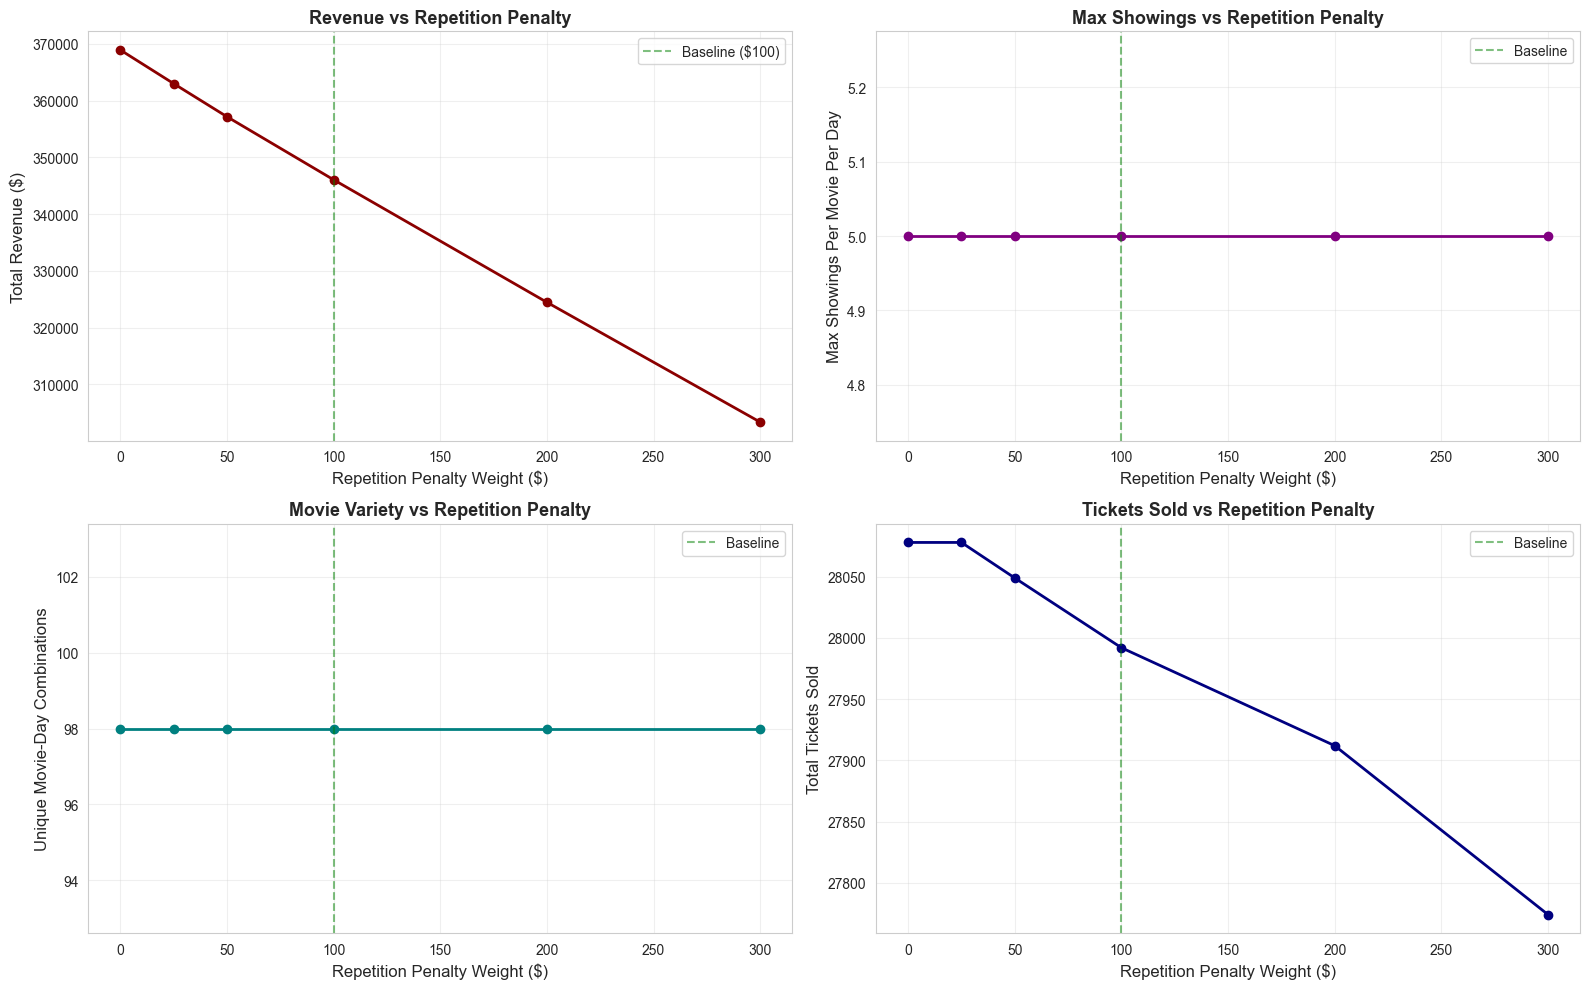


Key Findings:
  Revenue at $0 penalty: $368,918.40
  Revenue at baseline ($100): $346,048.47
  Max showings at $0 penalty: 5
  Max showings at high penalty ($500): 5
  Unique movies at $0 penalty: 98
  Unique movies at high penalty: 98


In [15]:

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue vs Repetition Penalty
axes[0, 0].plot(repetition_df['repetition_penalty_weight'], repetition_df['revenue'], 
                marker='o', linewidth=2, color='darkred')
axes[0, 0].axvline(REPETITION_PENALTY_WEIGHT, color='green', linestyle='--', 
                   label=f'Baseline (${REPETITION_PENALTY_WEIGHT})', alpha=0.5)
axes[0, 0].set_xlabel('Repetition Penalty Weight ($)', fontsize=12)
axes[0, 0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0, 0].set_title('Revenue vs Repetition Penalty', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Max Showings Per Movie Per Day vs Penalty
axes[0, 1].plot(repetition_df['repetition_penalty_weight'], repetition_df['max_showings_per_movie_day'], 
                marker='o', linewidth=2, color='purple')
axes[0, 1].axvline(REPETITION_PENALTY_WEIGHT, color='green', linestyle='--', 
                   label=f'Baseline', alpha=0.5)
axes[0, 1].set_xlabel('Repetition Penalty Weight ($)', fontsize=12)
axes[0, 1].set_ylabel('Max Showings Per Movie Per Day', fontsize=12)
axes[0, 1].set_title('Max Showings vs Repetition Penalty', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Unique Movie-Days vs Penalty
axes[1, 0].plot(repetition_df['repetition_penalty_weight'], repetition_df['unique_movie_days'], 
                marker='o', linewidth=2, color='teal')
axes[1, 0].axvline(REPETITION_PENALTY_WEIGHT, color='green', linestyle='--', 
                   label=f'Baseline', alpha=0.5)
axes[1, 0].set_xlabel('Repetition Penalty Weight ($)', fontsize=12)
axes[1, 0].set_ylabel('Unique Movie-Day Combinations', fontsize=12)
axes[1, 0].set_title('Movie Variety vs Repetition Penalty', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Tickets vs Penalty
axes[1, 1].plot(repetition_df['repetition_penalty_weight'], repetition_df['tickets'], 
                marker='o', linewidth=2, color='navy')
axes[1, 1].axvline(REPETITION_PENALTY_WEIGHT, color='green', linestyle='--', 
                   label=f'Baseline', alpha=0.5)
axes[1, 1].set_xlabel('Repetition Penalty Weight ($)', fontsize=12)
axes[1, 1].set_ylabel('Total Tickets Sold', fontsize=12)
axes[1, 1].set_title('Tickets Sold vs Repetition Penalty', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_repetition_penalty.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Revenue at $0 penalty: ${repetition_df[repetition_df['repetition_penalty_weight'] == 0]['revenue'].values[0]:,.2f}")
print(f"  Revenue at baseline (${REPETITION_PENALTY_WEIGHT}): ${repetition_df[repetition_df['repetition_penalty_weight'] == REPETITION_PENALTY_WEIGHT]['revenue'].values[0]:,.2f}")
print(f"  Max showings at $0 penalty: {repetition_df[repetition_df['repetition_penalty_weight'] == 0]['max_showings_per_movie_day'].values[0]:.0f}")
print(f"  Max showings at high penalty ($500): {repetition_df[repetition_df['repetition_penalty_weight'] == 300]['max_showings_per_movie_day'].values[0]:.0f}")
print(f"  Unique movies at $0 penalty: {repetition_df[repetition_df['repetition_penalty_weight'] == 0]['unique_movie_days'].values[0]:.0f}")
print(f"  Unique movies at high penalty: {repetition_df[repetition_df['repetition_penalty_weight'] == 300]['unique_movie_days'].values[0]:.0f}")

Running movie diversity weight sensitivity analysis...
  Weight $0: Revenue $326,448.47, Unique movies 98
  Weight $50: Revenue $331,348.47, Unique movies 98
  Weight $100: Revenue $336,248.47, Unique movies 98
  Weight $200: Revenue $346,048.47, Unique movies 98
  Weight $300: Revenue $355,848.47, Unique movies 98
  Weight $500: Revenue $375,448.47, Unique movies 98
  Weight $1000: Revenue $424,448.47, Unique movies 98

Movie diversity weight analysis complete!


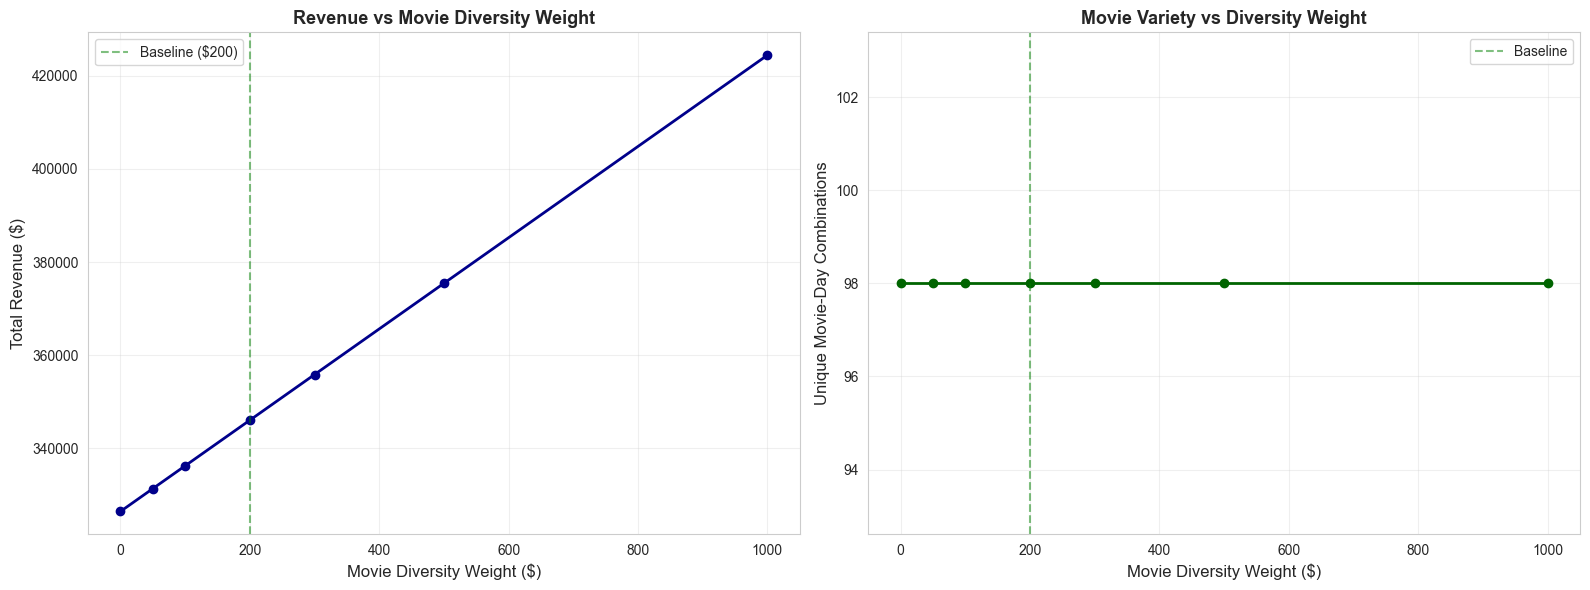


Key Findings:
  Revenue at $0 weight: $326,448.47
  Revenue at baseline ($200): $346,048.47
  Unique movies at $0 weight: 98
  Unique movies at high weight ($1000): 98
  Value of diversity bonus at baseline: $19,600.00


In [ ]:
# Test different movie diversity weights
movie_div_weights = [0, 50, 100, 200, 300, 500, 1000]
movie_div_results = []

print("Running movie diversity weight sensitivity analysis...")

for weight in movie_div_weights:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN,
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        repetition_penalty_weight=REPETITION_PENALTY_WEIGHT,
        movie_diversity_weight=weight,
        verbose=False
    )
    movie_div_results.append({
        'movie_diversity_weight': weight,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'unique_movie_days': result['unique_movie_days'],
        'max_showings_per_movie_day': result['max_showings_per_movie_day']
    })
    print(f"  Weight ${weight}: Revenue ${result['revenue']:,.2f}, Unique movies {result['unique_movie_days']:.0f}")

movie_div_df = pd.DataFrame(movie_div_results)
print("\nMovie diversity weight analysis complete!")

# Export
movie_div_df.to_csv(results_dir / 'sensitivity_movie_diversity.csv', index=False)

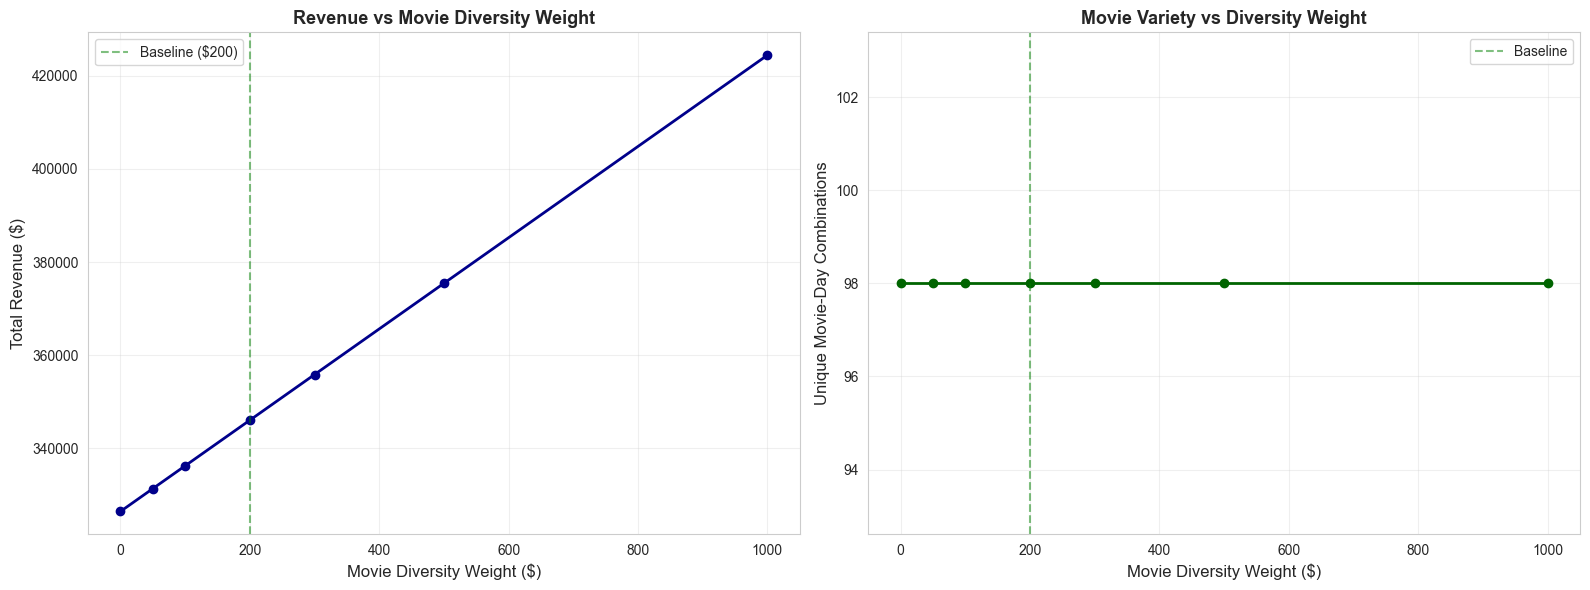


Key Findings:
  Revenue at $0 weight: $326,448.47
  Revenue at baseline ($200): $346,048.47
  Unique movies at $0 weight: 98
  Unique movies at high weight ($1000): 98
  Value of diversity bonus at baseline: $19,600.00


In [17]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue vs Movie Diversity Weight
axes[0].plot(movie_div_df['movie_diversity_weight'], movie_div_df['revenue'], 
            marker='o', linewidth=2, color='darkblue')
axes[0].axvline(MOVIE_DIVERSITY_WEIGHT, color='green', linestyle='--', 
                label=f'Baseline (${MOVIE_DIVERSITY_WEIGHT})', alpha=0.5)
axes[0].set_xlabel('Movie Diversity Weight ($)', fontsize=12)
axes[0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0].set_title('Revenue vs Movie Diversity Weight', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Unique Movie-Days vs Weight
axes[1].plot(movie_div_df['movie_diversity_weight'], movie_div_df['unique_movie_days'], 
            marker='o', linewidth=2, color='darkgreen')
axes[1].axvline(MOVIE_DIVERSITY_WEIGHT, color='green', linestyle='--', 
                label=f'Baseline', alpha=0.5)
axes[1].set_xlabel('Movie Diversity Weight ($)', fontsize=12)
axes[1].set_ylabel('Unique Movie-Day Combinations', fontsize=12)
axes[1].set_title('Movie Variety vs Diversity Weight', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_movie_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Revenue at $0 weight: ${movie_div_df[movie_div_df['movie_diversity_weight'] == 0]['revenue'].values[0]:,.2f}")
print(f"  Revenue at baseline (${MOVIE_DIVERSITY_WEIGHT}): ${movie_div_df[movie_div_df['movie_diversity_weight'] == MOVIE_DIVERSITY_WEIGHT]['revenue'].values[0]:,.2f}")
print(f"  Unique movies at $0 weight: {movie_div_df[movie_div_df['movie_diversity_weight'] == 0]['unique_movie_days'].values[0]:.0f}")
print(f"  Unique movies at high weight ($1000): {movie_div_df[movie_div_df['movie_diversity_weight'] == 1000]['unique_movie_days'].values[0]:.0f}")
diversity_value = (movie_div_df[movie_div_df['movie_diversity_weight'] == MOVIE_DIVERSITY_WEIGHT]['revenue'].values[0] - 
                  movie_div_df[movie_div_df['movie_diversity_weight'] == 0]['revenue'].values[0])
print(f"  Value of diversity bonus at baseline: ${diversity_value:,.2f}")

## 4. Demand Sensitivity Analysis

In [42]:
# Test different demand multipliers
demand_multipliers = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
demand_results = []

print("Running demand sensitivity analysis...")

for multiplier in demand_multipliers:
    # Scale demand
    scaled_demand = {key: int(value * multiplier) for key, value in demand.items()}
    
    result = run_optimization(
        runtimes, scaled_demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, verbose=False
    )
    demand_results.append({
        'demand_multiplier': multiplier,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings']
    })
    print(f"  Demand {multiplier}x: Revenue ${result['revenue']:,.2f}")

demand_sens_df = pd.DataFrame(demand_results)
print("\nDemand analysis complete!")

Running demand sensitivity analysis...
  Demand 0.5x: Revenue $164,628.36
  Demand 0.75x: Revenue $246,919.92
  Demand 1.0x: Revenue $317,562.18
  Demand 1.25x: Revenue $372,879.39
  Demand 1.5x: Revenue $423,695.22
  Demand 2.0x: Revenue $495,581.58
  Demand 3.0x: Revenue $604,089.72

Demand analysis complete!


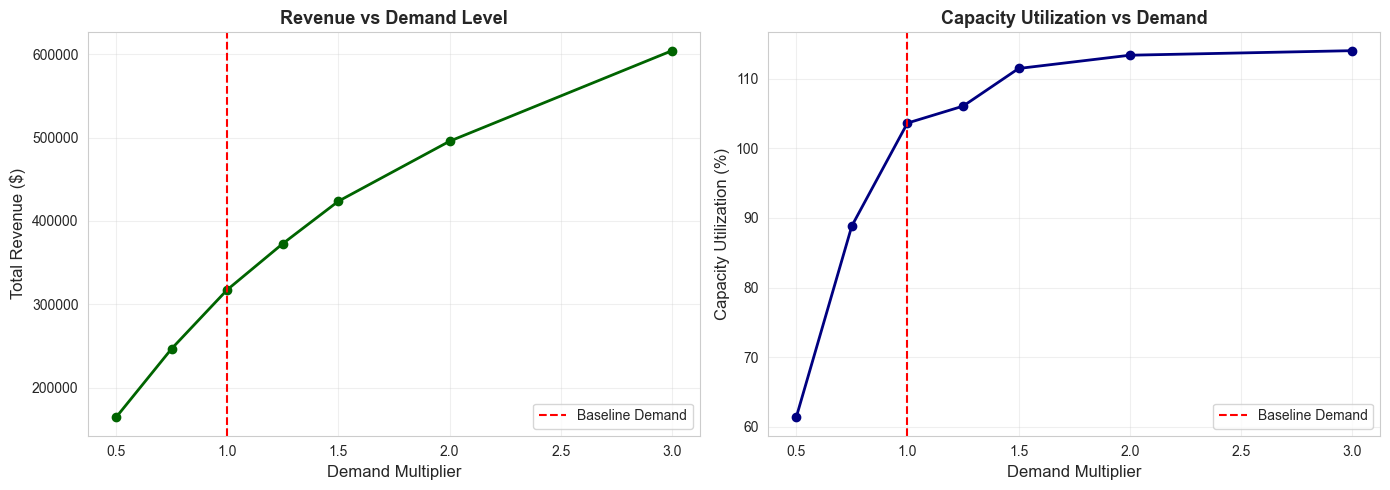

In [43]:
# Visualize demand sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Demand
axes[0].plot(demand_sens_df['demand_multiplier'], demand_sens_df['revenue'], 
             marker='o', linewidth=2, color='darkgreen')
axes[0].axvline(1.0, color='red', linestyle='--', label='Baseline Demand')
axes[0].set_xlabel('Demand Multiplier', fontsize=12)
axes[0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0].set_title('Revenue vs Demand Level', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Capacity Utilization vs Demand
demand_sens_df['utilization'] = demand_sens_df['tickets'] / (demand_sens_df['showings'] * 210)
axes[1].plot(demand_sens_df['demand_multiplier'], demand_sens_df['utilization'] * 100,
             marker='o', linewidth=2, color='navy')
axes[1].axvline(1.0, color='red', linestyle='--', label='Baseline Demand')
axes[1].set_xlabel('Demand Multiplier', fontsize=12)
axes[1].set_ylabel('Capacity Utilization (%)', fontsize=12)
axes[1].set_title('Capacity Utilization vs Demand', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_demand.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Operating Hours Sensitivity

In [44]:
# Test different operating hours
hours_range = [8, 10, 12, 14, 16, 18]
hours_results = []

print("Running operating hours sensitivity analysis...")

for hours in hours_range:
    operating_min_temp = {day: hours * 60 for day in DAYS}
    
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min_temp, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, verbose=False
    )
    hours_results.append({
        'operating_hours': hours,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings']
    })
    print(f"  {hours} hours: Revenue ${result['revenue']:,.2f}")

hours_df = pd.DataFrame(hours_results)
print("\nOperating hours analysis complete!")

Running operating hours sensitivity analysis...
  8 hours: Revenue $305,731.92
  10 hours: Revenue $317,562.18
  12 hours: Revenue $317,562.18
  14 hours: Revenue $317,562.18
  16 hours: Revenue $317,562.18
  18 hours: Revenue $317,562.18

Operating hours analysis complete!


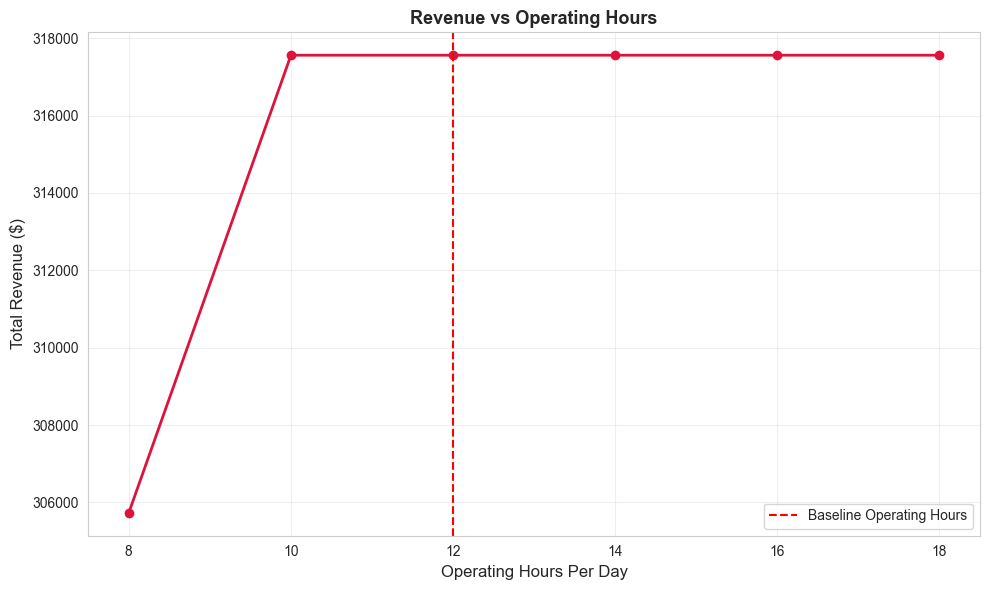

In [45]:
# Visualize operating hours sensitivity
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(hours_df['operating_hours'], hours_df['revenue'], marker='o', linewidth=2, color='crimson')
ax.axvline(BASELINE_OPERATING_HOURS, color='red', linestyle='--', label='Baseline Operating Hours')
ax.set_xlabel('Operating Hours Per Day', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_title('Revenue vs Operating Hours', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_operating_hours.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Price Elasticity Sensitivity Analysis

Testing how different elasticity values affect the optimal pricing strategy.

## 7. Genre Diversity Weight Sensitivity Analysis

Testing how the genre diversity bonus affects scheduling decisions and revenue.

In [12]:
# Test different elasticity values at different price points
elasticity_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
test_prices = [9, 11.31, 13, 15]
elasticity_results = []

print("Running price elasticity sensitivity analysis...")

for elasticity in elasticity_values:
    for price in test_prices:
        result = run_optimization(
            runtimes, demand, price, BASELINE_MAX_SHOWINGS,
            operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
            BASELINE_BUFFER_MIN,
            movie_genre_df=current,
            min_genres=MIN_GENRES,
            base_price=BASE_TICKET_PRICE,
            price_elasticity=elasticity,
            genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
            min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
            max_genre_bonus=MAX_GENRE_BONUS,
            verbose=False
        )
        elasticity_results.append({
            'elasticity': elasticity,
            'ticket_price': price,
            'revenue': result['revenue'],
            'tickets': result['tickets'],
            'avg_genres': result['avg_genres']
        })
    print(f"  Elasticity {elasticity:.1f} complete")

elasticity_df = pd.DataFrame(elasticity_results)
print("\nPrice elasticity analysis complete!")

# Find optimal price for each elasticity
print("\nOptimal price by elasticity:")
for elasticity in elasticity_values:
    subset = elasticity_df[elasticity_df['elasticity'] == elasticity]
    optimal_idx = subset['revenue'].idxmax()
    optimal = subset.loc[optimal_idx]
    print(f"  Elasticity {elasticity:.1f}: ${optimal['ticket_price']:.2f} → ${optimal['revenue']:,.2f}")

Running price elasticity sensitivity analysis...
  Elasticity 0.5 complete
  Elasticity 0.8 complete
  Elasticity 1.0 complete
  Elasticity 1.2 complete
  Elasticity 1.5 complete
  Elasticity 2.0 complete

Price elasticity analysis complete!

Optimal price by elasticity:
  Elasticity 0.5: $15.00 → $415,321.96
  Elasticity 0.8: $15.00 → $383,829.86
  Elasticity 1.0: $15.00 → $362,754.68
  Elasticity 1.2: $13.00 → $352,790.49
  Elasticity 1.5: $9.00 → $355,751.09
  Elasticity 2.0: $9.00 → $382,997.22


# Visualize elasticity sensitivity


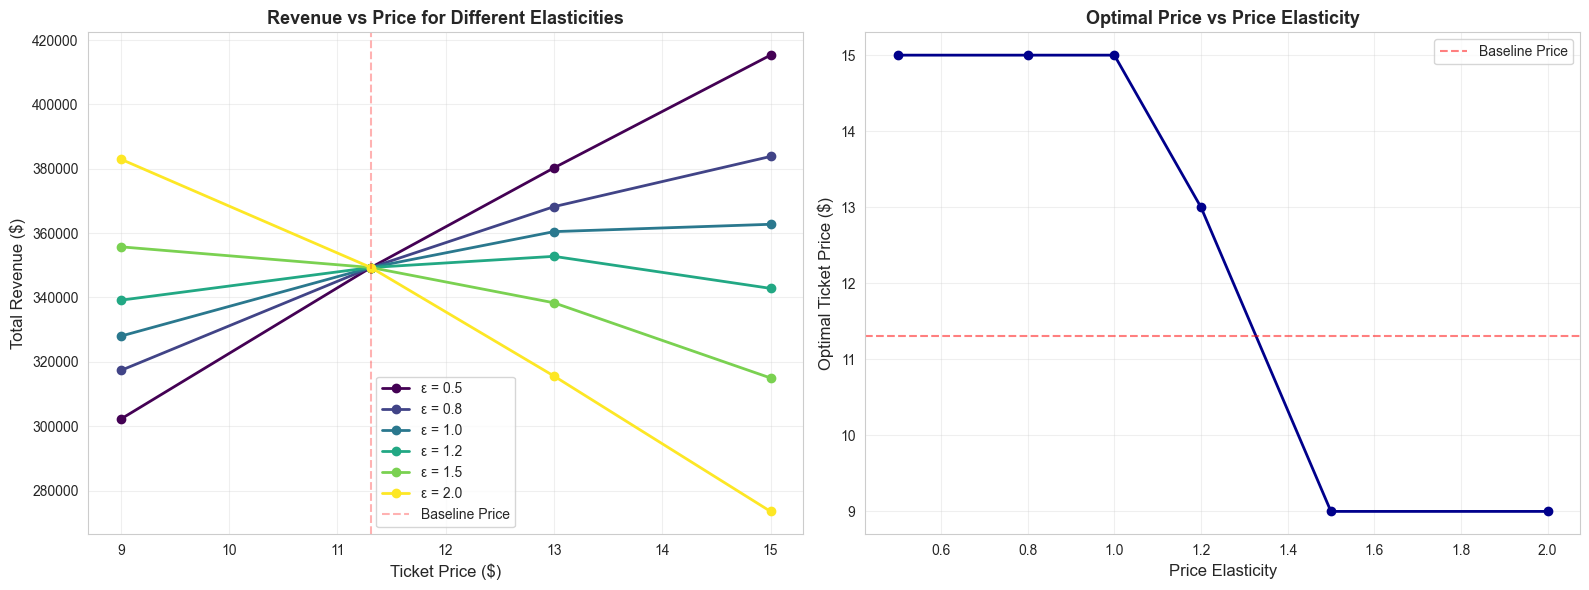

In [13]:
# Visualize elasticity sensitivity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue vs Price for different elasticities
colors = plt.cm.viridis(np.linspace(0, 1, len(elasticity_values)))
for i, elasticity in enumerate(elasticity_values):
    subset = elasticity_df[elasticity_df['elasticity'] == elasticity]
    axes[0].plot(subset['ticket_price'], subset['revenue'], 
                marker='o', linewidth=2, label=f'ε = {elasticity:.1f}', color=colors[i])

axes[0].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', alpha=0.3, label='Baseline Price')
axes[0].set_xlabel('Ticket Price ($)', fontsize=12)
axes[0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0].set_title('Revenue vs Price for Different Elasticities', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Optimal price vs elasticity
optimal_prices = []
optimal_revenues = []
for elasticity in elasticity_values:
    subset = elasticity_df[elasticity_df['elasticity'] == elasticity]
    optimal_idx = subset['revenue'].idxmax()
    optimal_prices.append(subset.loc[optimal_idx, 'ticket_price'])
    optimal_revenues.append(subset.loc[optimal_idx, 'revenue'])

axes[1].plot(elasticity_values, optimal_prices, marker='o', linewidth=2, color='darkblue')
axes[1].axhline(BASELINE_TICKET_PRICE, color='red', linestyle='--', alpha=0.5, label='Baseline Price')
axes[1].set_xlabel('Price Elasticity', fontsize=12)
axes[1].set_ylabel('Optimal Ticket Price ($)', fontsize=12)
axes[1].set_title('Optimal Price vs Price Elasticity', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_price_elasticity.png', dpi=300, bbox_inches='tight')
plt.show()